# KDD Cup 2010 Clustering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import linkage, dendrogram
import umap.umap_ as umap

C:\Users\youss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_PATH = 'algebra_2005_2006_train.txt'
df = pd.read_csv(DATA_PATH,sep='\t',low_memory=False)
print(df.shape)
display(df.head())
display(df.dtypes)

(809694, 19)


,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,1,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,3(x+2) = 15,2005-09-09 12:24:35.0,2005-09-09 12:24:49.0,2005-09-09 12:25:15.0,2005-09-09 12:25:15.0,40.0,NaN,40.0,0,2,3,1,[SkillRule: Eliminate Parens; {CLT nested; CLT...,1
1,2,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,x+2 = 5,2005-09-09 12:25:15.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,16.0,16.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",1~~1
2,3,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,2-8y = -4,2005-09-09 12:25:36.0,2005-09-09 12:25:43.0,2005-09-09 12:26:12.0,2005-09-09 12:26:12.0,36.0,NaN,36.0,0,2,3,1,"[SkillRule: Remove constant; {ax+b=c, positive...",2
3,4,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,-8y = -6,2005-09-09 12:26:12.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,2005-09-09 12:26:34.0,22.0,22.0,NaN,1,0,0,1,"[SkillRule: Remove coefficient; {ax+b=c, divid...",1~~1
4,5,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,2,-7y-5 = -4,2005-09-09 12:26:38.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,2005-09-09 12:28:36.0,118.0,118.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",3~~1


Row                              int64
Anon Student Id                 object
Problem Hierarchy               object
Problem Name                    object
Problem View                     int64
Step Name                       object
Step Start Time                 object
First Transaction Time          object
Correct Transaction Time        object
Step End Time                   object
Step Duration (sec)            float64
Correct Step Duration (sec)    float64
Error Step Duration (sec)      float64
Correct First Attempt            int64
Incorrects                       int64
Hints                            int64
Corrects                         int64
KC(Default)                     object
Opportunity(Default)            object
dtype: object

## Data cleaning

first numeric conversion

In [4]:
numeric_cols = ['Correct First Attempt','Step Duration (sec)',
'Correct Step Duration (sec)','Error Step Duration (sec)']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col],errors='coerce')


df['Opportunity_Num'] = pd.to_numeric(
    df['Opportunity(Default)'].astype(str).str.split('~~').str[0],
    errors='coerce'
)

df['Hints'] = pd.to_numeric(df['Hints'],errors='coerce')


### Split skills

In [5]:
df['KC(Default)'] = df['KC(Default)'].fillna('Unknown')
df['KC_List'] = df['KC(Default)'].astype(str).str.split('~~')
skill_df = df.explode('KC_List')
print('Original rows:',len(df))
print('Rows after KC expansion:',len(skill_df))

Original rows: 809694
Rows after KC expansion: 1086771


### Duration outliers

log transform and remove all negative times

In [6]:
df['duration_log'] = np.log1p(df['Step Duration (sec)'].clip(lower=0))

## Student information

In [7]:
group = df.groupby('Anon Student Id')

student = pd.DataFrame(index=group.size().index)

# interactions
student['total_interactions'] = group.size()
student['success_rate'] = group['Correct First Attempt'].mean()
student['incorrect_rate'] = 1 - student['success_rate']

# unique problems steps and skills
student['unique_problems'] = group['Problem Name'].nunique()
student['unique_steps'] = group['Step Name'].nunique()
student['unique_skills'] = skill_df.groupby('Anon Student Id')['KC_List'].nunique()
student['skill_diversity'] = student['unique_skills'] / student['total_interactions']

# duration stats
student['avg_log_duration'] = group['duration_log'].mean()
student['median_log_duration'] = group['duration_log'].median()
student['duration_variance'] = group['duration_log'].var()

# opportunity stats
student['avg_opportunity'] = group['Opportunity_Num'].mean()
student['max_opportunity'] = group['Opportunity_Num'].max()

# hints
student['avg_hints'] = group['Hints'].mean()
student['total_hints'] = group['Hints'].sum()

# use stats to make a struggle score 
student['struggle_score'] = student['incorrect_rate'].fillna(0)
student['struggle_score'] += student['avg_log_duration'].fillna(0)
student['struggle_score'] += student['avg_hints'].fillna(0)

## Skill mastery matrix

How good a student is at getting a skill correct

In [8]:
skill_mastery = pd.pivot_table(
    skill_df,
    index='Anon Student Id',
    columns='KC_List',
    values='Correct First Attempt',
    aggfunc='mean'
).fillna(0)

student['skill_mastery_variance'] = skill_mastery.var(axis=1)


## Final dataframe

In [9]:
X = student.join(skill_mastery,how='left')

for col in X.columns:
    X[col] = X[col].fillna(X[col].mean())

## PCA

In [10]:
X_scaled=StandardScaler().fit_transform(X)

# 95 percent of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print('Original features:',X.shape[1])
print('PCA components:',X_pca.shape[1])

Original features: 129
PCA components: 53


## UMAP

Didnt take
better at capturing groupings?

In [11]:
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_scaled)

C:\Users\youss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Select K (cluster count) using silhoutte score

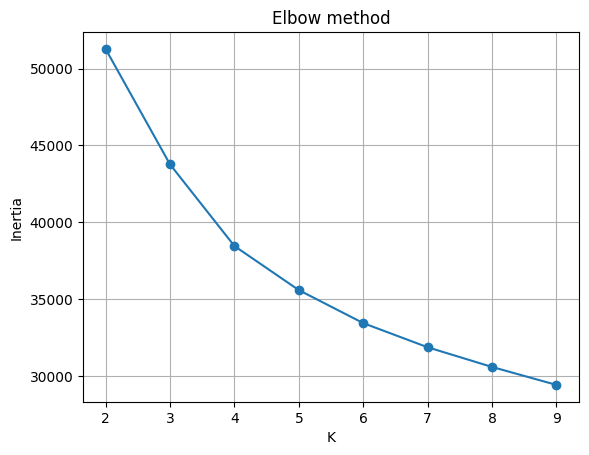

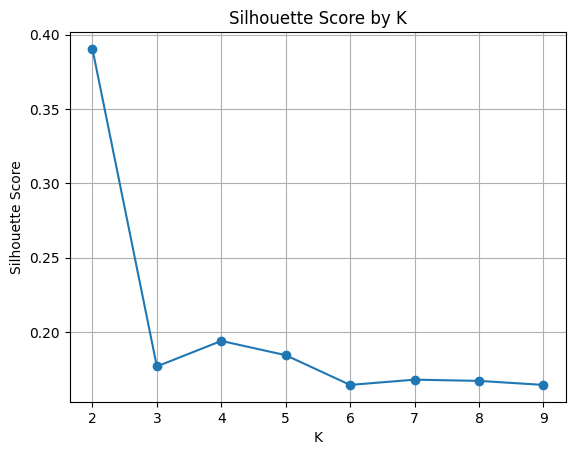

Best K= 2


In [12]:
scores = []
inertias = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k,n_init=20,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca,labels))
    inertias.append(kmeans.inertia_)

plt.plot(range(2,10),inertias,marker='o')
plt.title('Elbow method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

plt.plot(range(2,10),scores,marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = np.argmax(scores)+2
print('Best K=',best_k)

## Train clustering models

K means 

Herarchical Didnt take (relationships between data points)

guassian mixture Didnt take (non circular patterns)

In [39]:
k_labels = KMeans(n_clusters=best_k,n_init=20,random_state=42).fit_predict(X_pca)
h_labels = AgglomerativeClustering(n_clusters=best_k).fit_predict(X_pca)
gmm = GaussianMixture(n_components=best_k,random_state=42)
g_labels = gmm.fit_predict(X_pca)
dbscan = DBSCAN(eps=9.0,min_samples=10)
db_labels = dbscan.fit_predict(X_pca)

## Model comparison 

silhouette score (how similar a point is to its cluster vs others)

Davies bouldin index Didnt take (how similar a cluster is to other clusters)

calinski harabasz index Didnt take (cluster dispertion ratio)

In [40]:
# function in case DBSCAN returns less than 2 real clusters

def clustering_metrics(data, labels):
    clusters = set(labels) - {-1}
    if len(clusters) < 2:
        return [np.nan,np.nan,np.nan]

    return [
        silhouette_score(data, labels),
        davies_bouldin_score(data, labels),
        calinski_harabasz_score(data, labels)
    ]


comparison_model = pd.DataFrame([
['KMeans', *clustering_metrics(X_pca,k_labels)],
['Hierarchical', *clustering_metrics(X_pca,h_labels)],
['GMM', *clustering_metrics(X_pca,g_labels)],
['DBSCAN', *clustering_metrics(X_pca,db_labels)]
],columns=['Model','Silhouette','DBI','CHI'])

print('DBSCAN clusters:',len(set(db_labels) - {-1}))
print('DBSCAN noise points:',np.sum(db_labels == -1))
display(comparison_model.sort_values('Silhouette',ascending=False))

DBSCAN clusters: 2
DBSCAN noise points: 90


,Model,Silhouette,DBI,CHI
0,KMeans,0.390421,1.380951,182.400902
1,Hierarchical,0.385189,1.438039,178.898374
2,GMM,0.366843,1.475940,173.788883
3,DBSCAN,0.305705,2.436505,79.516506


## Heirachical dendogram

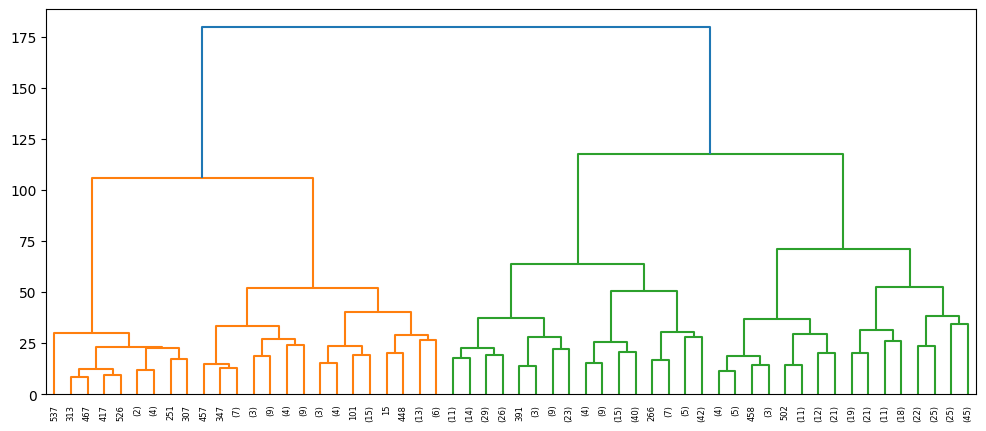

In [41]:
plt.figure(figsize=(12,5))
Z = linkage(X_pca,method='ward')
dendrogram(Z,truncate_mode='level',p=5)
plt.show()

## PCA visualization

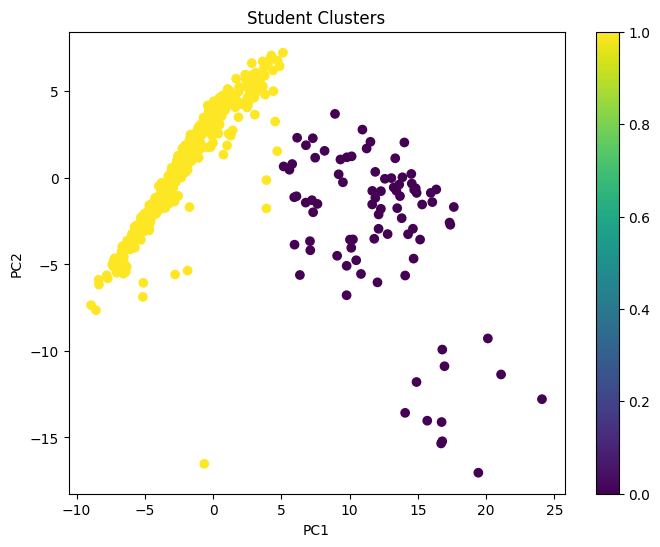

In [42]:
X2 = PCA(
    n_components=2
).fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X2[:,0],
    X2[:,1],
    c=k_labels
)

plt.title(
    'Student Clusters'
)

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(scatter)

plt.show()

## UMAP visualization

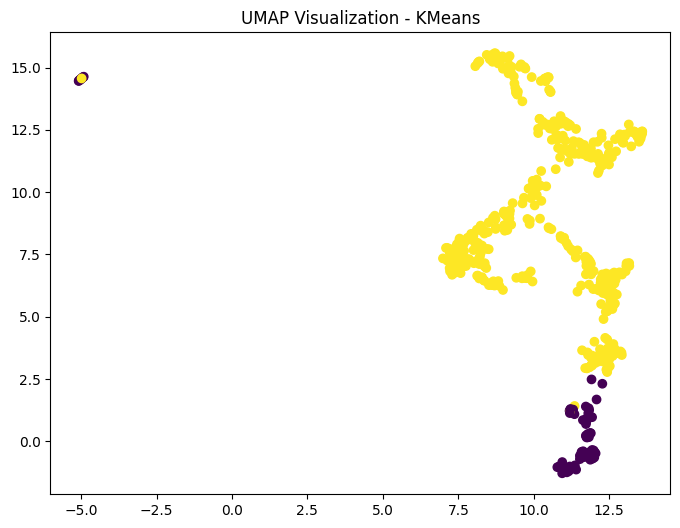

In [43]:
best_model=comparison_model.sort_values('Silhouette',ascending=False).iloc[0]['Model']
labels = {'KMeans':k_labels,'Hierarchical':h_labels,'GMM':g_labels,'DBSCAN':db_labels}[best_model]

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0],X_umap[:,1],c=labels)
plt.title(f'UMAP Visualization - {best_model}')
plt.show()

## Compare PCA to non PCA

In [19]:
k_labels_nonPCA = KMeans(n_clusters=best_k,n_init=20,random_state=42).fit_predict(X_scaled)

comparison_pca = pd.DataFrame([
['KMeans PCA',silhouette_score(X_pca,k_labels),davies_bouldin_score(X_pca,k_labels),calinski_harabasz_score(X_pca,k_labels)],
['KMeans non PCA',silhouette_score(X_scaled,k_labels_nonPCA),davies_bouldin_score(X_scaled,k_labels_nonPCA),calinski_harabasz_score(X_scaled,k_labels_nonPCA)],
],columns=['Model','Silhouette','DBI','CHI'])

display(comparison_pca.sort_values('Silhouette',ascending=False))

,Model,Silhouette,DBI,CHI
0,KMeans PCA,0.390421,1.380951,182.400902
1,KMeans non PCA,0.380849,1.438060,170.654097


## Cluster profiles

information about clusters

In [20]:
student['cluster'] = labels
cluster_profiles = student.groupby('cluster').mean()
display(cluster_profiles)

,total_interactions,success_rate,incorrect_rate,unique_problems,unique_steps,unique_skills,skill_diversity,avg_log_duration,median_log_duration,duration_variance,avg_opportunity,max_opportunity,avg_hints,total_hints,struggle_score,skill_mastery_variance
cluster,,,,,,,,,,,,,,,,
0,3990.255814,0.793056,0.206944,258.000000,1389.755814,84.534884,0.027000,2.517419,2.330199,1.061997,112.153076,503.651163,0.245286,1070.034884,2.969649,0.134580
1,956.008197,0.765159,0.234841,67.317623,407.551230,34.711066,0.093928,2.798808,2.629658,1.107937,34.423967,136.065574,0.289226,313.311475,3.322875,0.111688


## Cluster naming

In [45]:
persona_report = cluster_profiles.copy()
persona_report['Persona'] = 'General Learner'

for idx,row in persona_report.iterrows():
    if row['success_rate'] > persona_report['success_rate'].mean():
        persona_report.loc[idx,'Persona'] = 'High Achiever'
    elif row['incorrect_rate'] > persona_report['incorrect_rate'].mean():
        persona_report.loc[idx,'Persona'] = 'Struggling Learner'

persona_report['size'] = pd.Series(k_labels).value_counts()
display(persona_report)

,total_interactions,success_rate,incorrect_rate,unique_problems,unique_steps,unique_skills,skill_diversity,avg_log_duration,median_log_duration,duration_variance,avg_opportunity,max_opportunity,avg_hints,total_hints,struggle_score,skill_mastery_variance,Persona,size
cluster,,,,,,,,,,,,,,,,,,
0,3990.255814,0.793056,0.206944,258.000000,1389.755814,84.534884,0.027000,2.517419,2.330199,1.061997,112.153076,503.651163,0.245286,1070.034884,2.969649,0.134580,High Achiever,86
1,956.008197,0.765159,0.234841,67.317623,407.551230,34.711066,0.093928,2.798808,2.629658,1.107937,34.423967,136.065574,0.289226,313.311475,3.322875,0.111688,Struggling Learner,488
